# **White Blood Cell Classifier**

### **Problem Statement**

The manual classification of White Blood Cells (WBCs) from microscopic images is a challenging and time-consuming task that requires expert knowledge. Differences in cell appearance and the large number of samples to be analyzed can make the process prone to errors and inconsistencies.

This project aims to develop an automated WBC classification system capable of identifying four types of white blood cells: Eosinophil, Lymphocyte, Monocyte, and Neutrophil. The primary focus of this project is to understand the role of image preprocessing in preparing raw image data for machine learning models and to analyze how these preprocessing techniques affect classification performance. Multiple machine learning algorithms are trained and compared to determine the most effective model for this classification task.



### **Objective**


- To build a White Blood Cell (WBC) image classification model.  
- To focus on effective image preprocessing techniques for medical images.  
- To understand how raw images are transformed into model-ready inputs.  
- To study the impact of preprocessing on model performance and accuracy.  
- To apply normalization and standardization for consistent image data.  
- To develop a reliable pipeline for image-based deep learning classification.

### **Dataset Overview**

- The dataset consists of White Blood Cell (WBC) images used for classification tasks.  
- It contains a total of 4 classes.  
- Each class has its own separate folder of images.  
- The classes included are:
  - Eosinophil  
  - Lymphocyte  
  - Monocyte  
  - Neutrophil  
- Each class contains 500 images, making the dataset balanced across all categories.  
- The images are used to train a model for automatic WBC classification based on visual features.

Dataset Link: https://www.kaggle.com/datasets/unclesamulus/blood-cells-image-dataset

### **# Import all the necessart Modules/Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "16"  

from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,recall_score,f1_score,precision_score

from tabulate import tabulate

import joblib

## **1. Converting Image Dataset into Numerical Dataset**

### **1.1 Image Preprocessing Pipeline**

- **Outer loop** iterates over each class folder (e.g., `Basophil`, `Eosinophil`, etc.) in the dataset directory
- **`os.chdir(new_path)`** navigates into each class folder so the inner loop can access its images
- **`cv2.imread(img)`** reads each image as a NumPy array in BGR format
- **`cv2.resize(..., (64,64))`** standardizes all images to a fixed 64×64 pixel size — required for consistent feature vector length
- **`cv2.cvtColor(..., COLOR_BGR2GRAY)`** converts the image to grayscale, reducing 3 color channels to 1 — simplifies computation without losing structural info
- **`cv2.GaussianBlur(..., (5,5), 0)`** applies Gaussian smoothing to reduce noise before edge detection
- **`.flatten()`** converts the 2D edge-detected image (64×64) into a 1D array of 4096 values — this becomes one feature vector
- **`rows.append()`** and **`label.append(item)`** collect the feature vector and its class label (folder name) for building the final dataset

In [3]:
origin = r"F:\Innomatics\Class\7. AI_ML\Projects\Project-3_Blood_Cell_Classifier\Dataset"
os.chdir(origin)

rows = []
label = []

for item in os.listdir():
    new_path = origin + '\\' + item
    os.chdir(new_path)
    for img in os.listdir():
        img_arr = cv2.imread(img)
        resized = cv2.resize(img_arr,(64,64))
        grayscaled_img = cv2.cvtColor(resized,cv2.COLOR_BGR2GRAY)
        blurred_img = cv2.GaussianBlur(grayscaled_img,(5,5),0)
        flaterned_arr = blurred_img.flatten()
        rows.append(flaterned_arr)
        label.append(item)


### **1.2 Creating the Image Dataframe that we processed above**

In [4]:
rows_df = pd.DataFrame(rows,dtype = np.uint8)

### **1.3 Creating the Labels Dataframe that we processed above**

In [5]:
label_df = pd.DataFrame(label,columns=['blood_class'])

### **1.4 Concating Both the dataframes into one Final `blood_df`**

In [6]:
blood_df = pd.concat([rows_df,label_df],axis=1)

In [7]:
blood_df.head()

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,blood_class
0,232,233,233,234,234,233,228,215,198,188,...,186,184,187,193,203,216,226,229,228,eosinophil
1,234,234,232,222,203,186,179,179,182,186,...,197,204,215,226,231,232,233,235,235,eosinophil
2,233,233,232,228,212,187,170,166,169,177,...,233,232,232,232,232,232,233,233,233,eosinophil
3,169,171,174,176,175,173,171,169,169,175,...,211,204,194,186,183,187,200,216,223,eosinophil
4,196,203,216,222,218,205,190,179,181,197,...,234,233,233,233,234,234,235,235,235,eosinophil


## **2. EXPLORATORY DATA ANALYSIS (EDA)**

**Section Summary:**

In this section, we explore the dataset to understand class distribution, visualize sample images, and extract initial patterns from pixel-level features before preprocessing and model training.

**2.1. Sample Images per Class**
- We visualize random sample images from each WBC class to understand visual differences and get an initial sense of intra-class and inter-class variation.

**2.2 Blood Cell Class Distribution**
- We analyze the distribution of images across the four classes using a bar plot to ensure dataset balance and identify any class imbalance issues.

**2.3 Image Preprocessing Visualization**
- We display step-by-step preprocessing transformations using subplots to understand how raw images are converted into model-ready inputs.

**2.4 Average Pixel Intensity per Class**
- We compare the average pixel intensity across classes using a bar plot to identify potential differences in brightness patterns that may help classification.

### **2.1 Sample Images per Class**

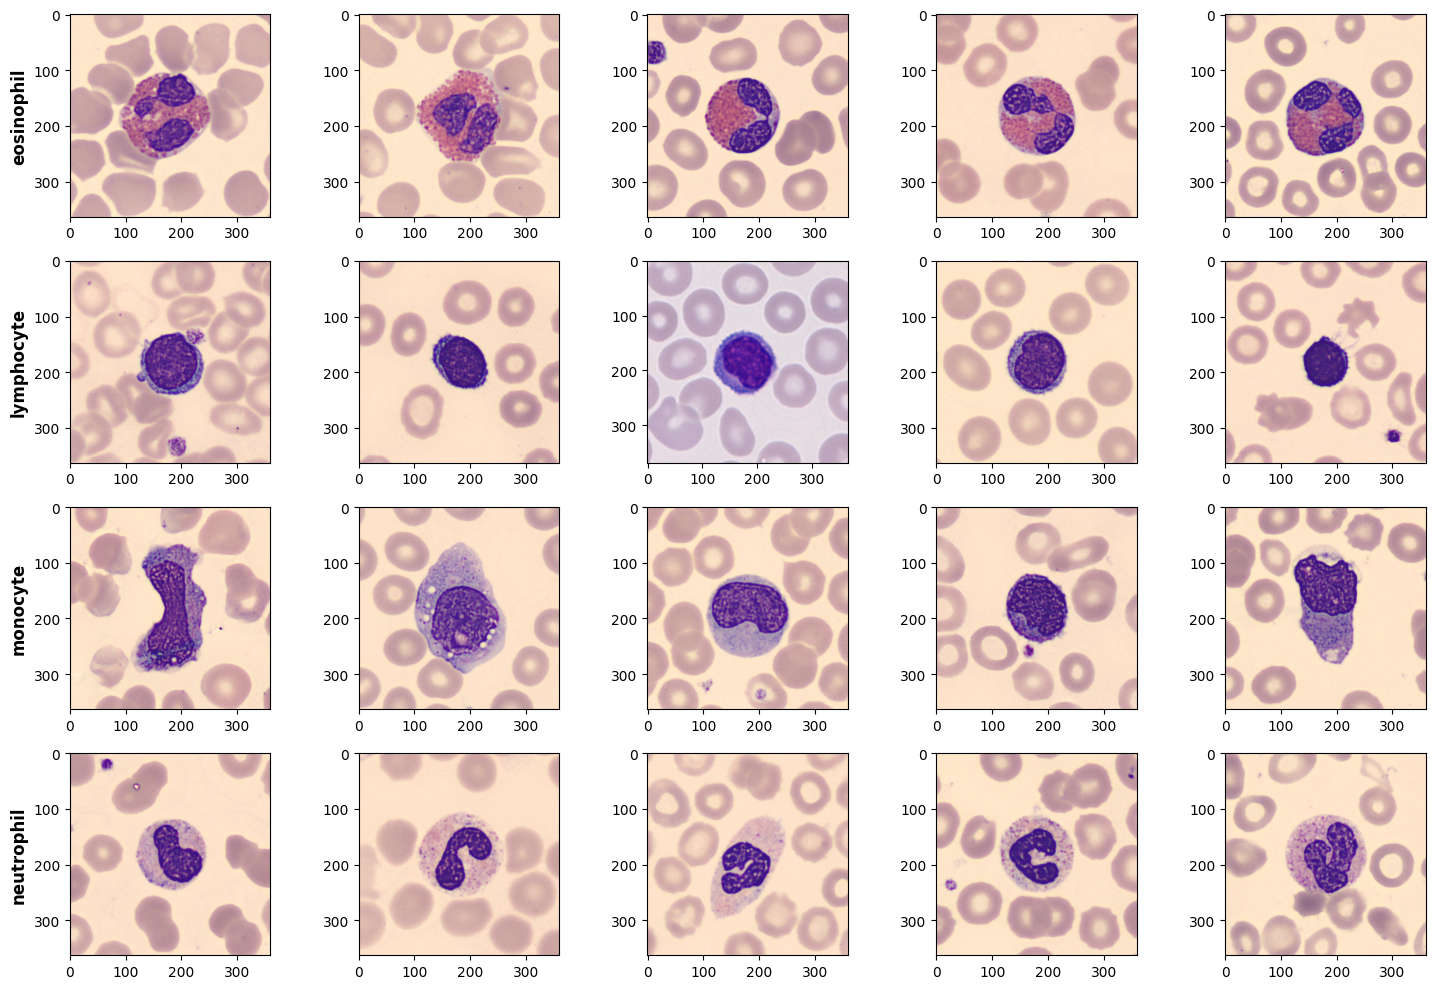

In [8]:
origin = r"F:\Innomatics\Class\7. AI_ML\Projects\Project-3_Blood_Cell_Classifier\Dataset"
os.chdir(origin)

fig , ax = plt.subplots(nrows=4,ncols=5,figsize=(15,10))
for row, folder in enumerate(os.listdir()):
    current_path = origin + '\\' + folder
    os.chdir(current_path)
    first_5_images = os.listdir(current_path)[:5]
    for col ,img in enumerate(first_5_images):
        image = cv2.imread(img)
        convert_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        ax[row,col].imshow(convert_rgb)

        if col == 0:
            ax[row, col].set_ylabel(folder, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


**Observations:**

- From the images above, we can see that the dataset contains four types of white blood cells: Eosinophil, Lymphocyte, Monocyte, and Neutrophil. 
- Each type of cell looks different in shape and structure. Some cells have larger nuclei, while others have segmented nuclei or visible granules. 
- These differences can help the model learn and classify the cells correctly.


### **2.2 Class Distribution Per Class**

In [9]:
class_counts = blood_df['blood_class'].value_counts()
class_counts

blood_class
eosinophil    500
lymphocyte    500
monocyte      500
neutrophil    500
Name: count, dtype: int64

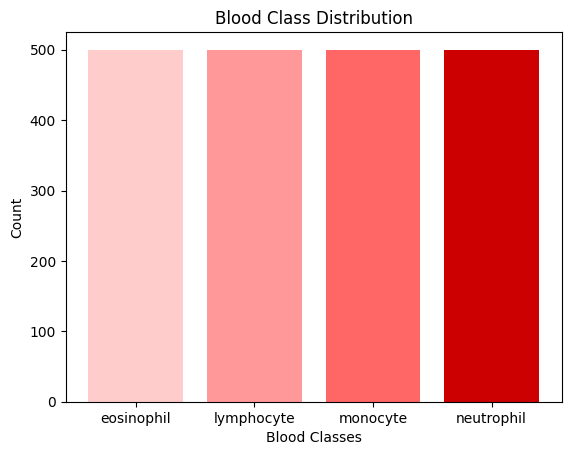

In [10]:
plt.title("Blood Class Distribution")
plt.xlabel("Blood Classes")
plt.ylabel("Count")
plt.bar(class_counts.index,class_counts,color = ['#ffcccc','#ff9999','#ff6666','#cc0000'])
plt.show()

**Observations:**

- Each blood cell class contains approximately 500 images.
- The number of samples is almost the same for all classes.
- The dataset appears to be balanced.
- A balanced dataset helps reduce bias toward any particular class during model training.

### **2.3 Image Preprocessing Process Visualization**

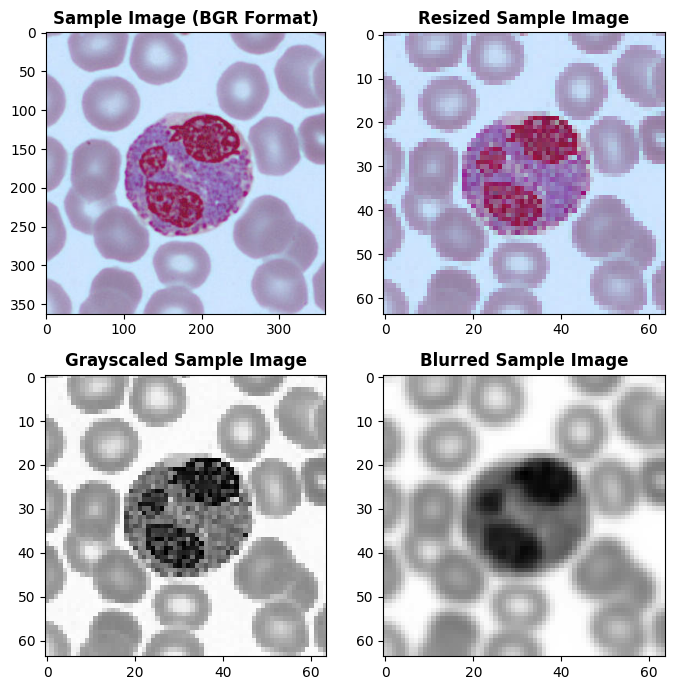

In [11]:
img_path = r"F:\Innomatics\Class\7. AI_ML\Projects\Project-3_Blood_Cell_Classifier\Dataset\eosinophil\EO_27.jpg"

sample_img = cv2.imread(img_path)
resizing_img = cv2.resize(sample_img,(64,64))
grayscaled_img = cv2.cvtColor(resizing_img,cv2.COLOR_BGR2GRAY)
blurred_img = cv2.GaussianBlur(grayscaled_img,(5,5),0)
edge_detect = cv2.Canny(blurred_img, 150,250)

fig , ax = plt.subplots(nrows=2,ncols=2,figsize=(7,7))
ax[0,0].set_title("Sample Image (BGR Format)",weight='bold')
ax[0,0].imshow(sample_img)
ax[0,1].set_title("Resized Sample Image",weight='bold')
ax[0,1].imshow(resizing_img)
ax[1,0].set_title("Grayscaled Sample Image",weight='bold')
ax[1,0].imshow(grayscaled_img,cmap='gray')
ax[1,1].set_title("Blurred Sample Image",weight='bold')
ax[1,1].imshow(blurred_img,cmap='gray')

plt.tight_layout()
plt.show()

**Observations**

* The original image contains color information and detailed cell structures.
* Resizing the image to 64 × 64 pixels reduces computational cost while preserving the important features of the blood cell.
* Converting the image to grayscale simplifies the data by reducing it to a single channel.
* Applying blur helps reduce noise, but too much blurring can also remove useful details.
* Overall, the preprocessing steps make the images more suitable for machine learning models.


### **2.4 Average Pixel Intensity Per Class**

- Pixel intensity represents the brightness value of a pixel in a grayscale image, ranging from 0 (black) to 255 (white).
- The average pixel intensity of an image is calculated by taking the mean of all its pixel values, providing an overall measure of the image's brightness.

- In this analysis, the average pixel intensity is computed for each image and then grouped by blood cell class.
- This helps us compare whether certain classes tend to have brighter or darker images on average. Although brightness alone may not be sufficient for classification, it provides useful insights into the characteristics of the dataset.

In [12]:
blood_df['avg_pixel_intensity'] = blood_df.iloc[:, :-1].mean(axis=1)

In [13]:
blood_df

,0,1,2,3,4,5,6,7,8,9,...,4088,4089,4090,4091,4092,4093,4094,4095,blood_class,avg_pixel_intensity
0,232,233,233,234,234,233,228,215,198,188,...,184,187,193,203,216,226,229,228,eosinophil,188.820312
1,234,234,232,222,203,186,179,179,182,186,...,204,215,226,231,232,233,235,235,eosinophil,196.880615
2,233,233,232,228,212,187,170,166,169,177,...,232,232,232,232,232,233,233,233,eosinophil,192.581299
3,169,171,174,176,175,173,171,169,169,175,...,204,194,186,183,187,200,216,223,eosinophil,200.923096
4,196,203,216,222,218,205,190,179,181,197,...,233,233,233,234,234,235,235,235,eosinophil,196.113281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,233,232,225,204,177,161,165,180,192,191,...,232,232,233,233,232,232,232,232,neutrophil,206.078369
1996,234,234,234,234,234,234,234,234,234,234,...,235,235,235,234,234,234,234,234,neutrophil,207.398438
1997,193,200,215,227,232,234,234,234,234,234,...,199,190,190,195,201,205,204,203,neutrophil,201.763184
1998,174,176,182,195,211,224,230,231,232,232,...,228,230,231,229,224,219,216,215,neutrophil,202.275391


In [14]:
avg_intensity = blood_df.groupby('blood_class')['avg_pixel_intensity'].mean().sort_values()
print("Average Pixel Intensity Per Blood Class:")
print(avg_intensity)

Average Pixel Intensity Per Blood Class:
blood_class
monocyte      193.562324
eosinophil    197.794272
neutrophil    199.784705
lymphocyte    200.169112
Name: avg_pixel_intensity, dtype: float64


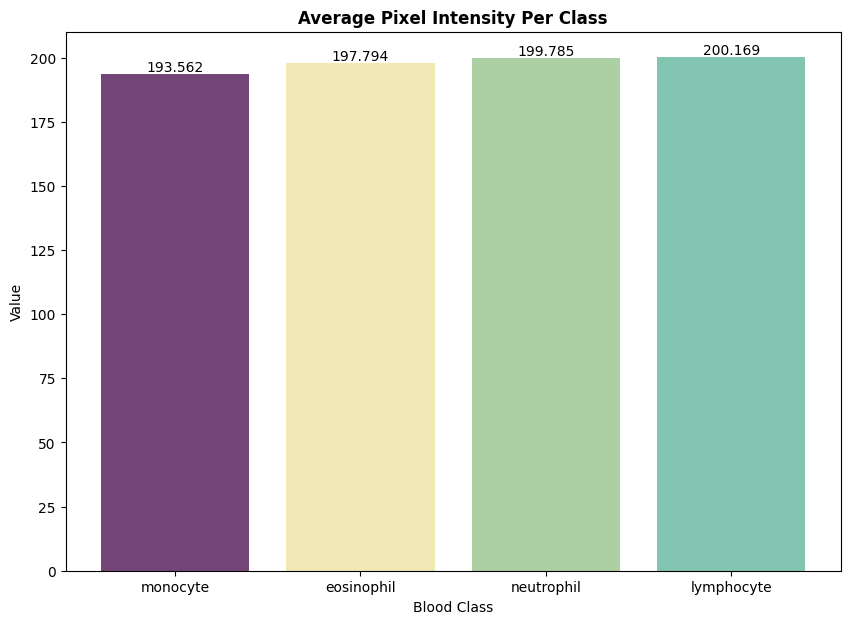

In [15]:
plt.figure(figsize=(10,7))
plt.title("Average Pixel Intensity Per Class",weight='bold')
bar = plt.bar(avg_intensity.index,avg_intensity,color=["#744577","#F0E9B6","#ACCFA3","#84C5B1"])
plt.bar_label(bar)
plt.xlabel("Blood Class")
plt.ylabel("Value")
plt.show()

**Observation:**

- Lymphocyte images are the brightest on average, while monocyte images are the darkest.
- Eosinophil and neutrophil images have similar brightness levels.
- Since the average pixel intensities are close to each other, brightness alone cannot effectively distinguish between the four blood cell classes.

Therefore, the model may rely more on structural features of the cells rather than overall image brightness.

## **3. Image Preprocessing**

**Section Summary:**
- In this section, the dataset is split into features (`X`) and labels (`y`).  
- The data is then divided into training and testing sets.  
- Image transformation techniques are applied to standardize and prepare the data for model input.  
- **MinMax scaling** is performed on `X_train` to normalize pixel values and improve model performance.  
- We use `fit_transform()` on the training data to learn the scaling parameters and apply the transformation at the same time.  
- For the test data, we use only `transform()` so that it uses the same learned scaling parameters without leaking information from the test set.  
- **Label encoding** is applied to `y_train` to convert categorical labels into numerical format.  
- The same preprocessing steps are applied to the test data to maintain consistency between training and testing pipelines.

In [16]:
blood_df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,4088,4089,4090,4091,4092,4093,4094,4095,blood_class,avg_pixel_intensity
0,232,233,233,234,234,233,228,215,198,188,...,184,187,193,203,216,226,229,228,eosinophil,188.820312
1,234,234,232,222,203,186,179,179,182,186,...,204,215,226,231,232,233,235,235,eosinophil,196.880615


### **3.1 Creating `X` and `y` for Model Building**

In [17]:
X = blood_df.drop(columns=['blood_class','avg_pixel_intensity'])
y = blood_df[['blood_class']]

### **3.2 Splitting the Data `X` and `y` into test and train**

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=1)

### **3.3 Applying Transformation and Scaling Techniques on `X_train` and `y_train`**

In [19]:
# Normalizing the Values
Scaler = MinMaxScaler().set_output(transform='pandas')

X_train_transf = Scaler.fit_transform(X_train)

In [20]:
X_train_transf.head(1)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x4086,x4087,x4088,x4089,x4090,x4091,x4092,x4093,x4094,x4095
0,0.975758,0.982249,0.982558,0.988166,0.988024,0.981818,0.949686,0.865385,0.75641,0.696203,...,0.722222,0.679487,0.648649,0.642857,0.658915,0.744361,0.832,0.927152,0.952381,0.947977


**Applying Label Encoder to our `y_train`**

In [21]:
LE = LabelEncoder()
y_train_transf = LE.fit_transform(y_train)

f:\Python Installer\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## **4. Model Training**

**Section Summary:**
- In this section, multiple machine learning algorithms are used to build the WBC classification model.  
- The main goal is to compare different models for image-based classification.  
- The following models are used:
  - `4.1. K-Nearest Neighbors (KNN)`
  - `4.2. Random Forest Classifier`
  - `4.3. Support Vector Machine (SVM)`
- Each model is trained on the processed image features extracted from the dataset.  
- The focus is on fitting the models using the prepared dataset after image preprocessing.

**Before Proceeding we need to reset the indexes of `X_Train_trans`**

In [22]:
X_train_transf.reset_index(inplace=True)
X_train_transf.pop('index')

0          0
1        816
2        790
3        361
4        592
        ... 
1595    1791
1596    1096
1597    1932
1598     235
1599    1061
Name: index, Length: 1600, dtype: int64

### **4.1 Creating the Model Uisng `K-Nearest Neighbours Algorithm (KNN)`**

In [23]:
KNN_Model = KNeighborsClassifier()
KNN_Model.fit(X_train_transf,y_train_transf)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### **4.2 Creating the Model using `Random Forest Classification Algorithm`**

In [24]:
RandForest_Model = RandomForestClassifier(n_estimators=100,random_state=1,class_weight='balanced')
RandForest_Model.fit(X_train_transf,y_train_transf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### **Creating the Model using `Support Vector Machine (SVM)`**

In [25]:
SVM_Model = SVC(kernel='rbf', C=1.0, random_state=1)
SVM_Model.fit(X_train_transf,y_train_transf)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## **5. Feature Engineering on `X_test` and `y_test`**

**Section Summary:**
- In this section, feature scaling and encoding are applied to prepare the test data for model input.  
- The `X_test` contains raw pixel values ranging from 0 to 255.  
- To normalize these values and bring them into a consistent range, **MinMaxScaler** is applied.  
- This helps improve model performance by ensuring all features are on the same scale.  
- The `y_test` contains categorical class labels (eosinophil, lymphocyte, monocyte, neutrophil).  
- These labels are converted into numerical format using **LabelEncoder**.  
- This encoding allows machine learning models to process the target labels effectively.

### **5.1 Normalizing our `X_test`**

In [26]:
X_test_transf = Scaler.transform(X_test)

In [27]:
X_test_transf.reset_index(inplace=True)
X_test_transf.pop('index')
X_test_transf.head(2)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x4086,x4087,x4088,x4089,x4090,x4091,x4092,x4093,x4094,x4095
0,0.993939,0.994083,0.994186,0.994083,0.994012,0.993939,0.993711,0.993590,0.987179,0.987342,...,0.777778,0.769231,0.763514,0.778571,0.837209,0.909774,0.936,0.933775,0.880952,0.849711
1,0.981818,0.982249,0.982558,0.982249,0.982036,0.981818,0.981132,0.980769,0.980769,0.974684,...,0.882716,0.903846,0.905405,0.857143,0.751938,0.661654,0.560,0.615894,0.654762,0.664740


### **5.2 Converting `y_test` from categorical to Numerical**

In [28]:
y_test_transf = LE.transform(y_test)

f:\Python Installer\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


## **6. Generating y_preds from different Models**

- We will predict outputs using our 3 different models
- And then we will compare these models based on evaluation metrics and select the best one for our purpose

#### **6.1 y_pred from `KNN_Model`**

In [29]:
y_pred_KNN = KNN_Model.predict(X_test_transf)

#### **6.2 y_pred from `RandForest_Model`**

In [30]:
y_pred_RandForest = RandForest_Model.predict(X_test_transf)

### **6.3 y_pred from `SVM`**

In [31]:
y_pred_SVM = SVM_Model.predict(X_test_transf)

## **7. Evaluation Metrics for our Models**

**Section Summary:**
- In this section, we evaluate the performance of all trained models on the test data.  
- Different evaluation metrics are used to measure how well each model is performing.  
- The main metrics used include:
  - Accuracy: Measures the overall correctness of predictions.  
  - Precision: Indicates how many predicted positives are actually correct.  
  - Recall: Measures how many actual positives are correctly identified.  
  - F1-Score: Harmonic mean of precision and recall for balanced evaluation.  
- A confusion matrix is used to understand the classification performance for each class in detail.  
- These metrics help in comparing KNN, Random Forest, and SVM to identify the best-performing model for WBC classification.

### **7.1 Accuracy Metrics for Each Models**

In [32]:
y_preds = {'Knn': y_pred_KNN,
           'RandForest': y_pred_RandForest,
           'SVM': y_pred_SVM}

table_data = []

for name,y_pred in y_preds.items():
    score = accuracy_score(y_test_transf,y_pred) * 100
    table_data.append([f"{name} Model", f"{score:.2f}%"])

print(tabulate(table_data, headers=["Model", "Accuracy Score"], tablefmt="grid"))

+------------------+------------------+
| Model            | Accuracy Score   |
+==================+==================+
| Knn Model        | 64.25%           |
+------------------+------------------+
| RandForest Model | 87.50%           |
+------------------+------------------+
| SVM Model        | 81.25%           |
+------------------+------------------+


**Observations:**

* The **Random Forest** model achieved the highest accuracy of **87.50%**, indicating the best performance among the three models.
* The **SVM** model obtained an accuracy of **81.25%**, demonstrating good classification performance but lower than Random Forest.
* The **KNN** model achieved the lowest accuracy of **64.25%**, suggesting that it was less effective for this dataset.
* Based on the accuracy scores, **Random Forest appears to be the most suitable model** for this classification task.
* Since accuracy alone does not provide a complete picture of model performance, additional metrics such as **Precision, Recall, F1-score, and the Confusion Matrix** should also be considered before selecting the final model.


### **7.2 Confusion Matrix for Each Models**

**7.2.1 Confusion Matrix for KNN Model**

- Before Moving forward we need the class name because Confusion matrix will give just the matrix without any labels
- So, How we can get the labels and all???
- We can find the label using `np.unique(y_test_transf)` -> It will give you the labels but as i already encoded my Target varible it is giving me some values like 0,1,2,3
- So, to check which number belongs to which class we will use `LE.classes_`

In [33]:
np.unique(y_test_transf)

array([0, 1, 2, 3])

In [34]:
LE.classes_

array(['eosinophil', 'lymphocyte', 'monocyte', 'neutrophil'], dtype=object)

In [35]:
cm_knn = confusion_matrix(y_test_transf,y_pred_KNN)
class_names = ['Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']

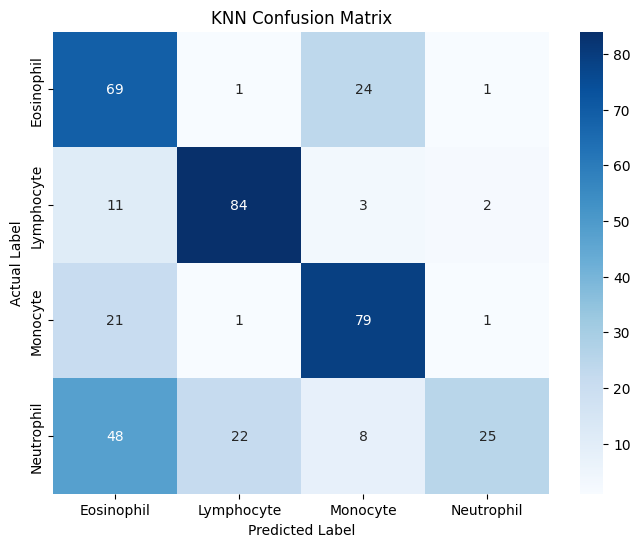

In [36]:
plt.figure(figsize=(8, 6))

sns.heatmap(cm_knn,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

**Observations:**

- Lymphocytes achieved the highest number of correct predictions (84), indicating that they were the easiest class for the KNN model to classify.
- Monocytes also showed good classification performance with 79 correct predictions.
- Neutrophils had the lowest number of correct predictions (25), suggesting that they were the most challenging class for the KNN model.
- The KNN model frequently confused Neutrophils with Eosinophils, as 48 Neutrophil samples were misclassified as Eosinophils.
- These results indicate that KNN struggled to distinguish certain blood cell classes with similar visual characteristics.

**7.2.2 Confusion Matrix for Random Forest Model**

In [37]:
cm_randforest = confusion_matrix(y_test_transf,y_pred_RandForest)
class_names = ['Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


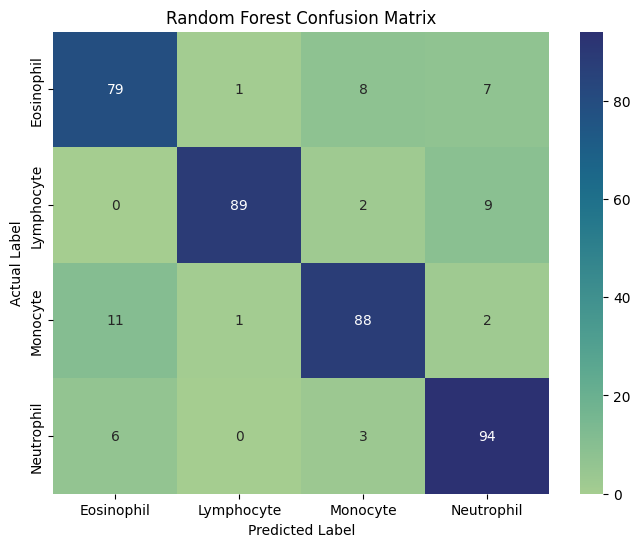

In [38]:
plt.figure(figsize=(8, 6))

sns.heatmap(cm_randforest,
            annot=True,
            fmt='d',
            cmap='crest',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

**Observations:**

- The Random Forest model achieved a high number of correct predictions across all blood cell classes.
- Neutrophils were classified most accurately, with 94 correct predictions.
- Lymphocytes and Monocytes also showed strong classification performance, with 89 and 88 correct predictions, respectively.
- Eosinophils had the lowest number of correct predictions (79), although the overall performance remained satisfactory.
- The most notable misclassification was observed between Monocytes and Eosinophils, where 11 Monocyte samples were predicted as Eosinophils.
- Compared to KNN, Random Forest exhibited fewer misclassifications and better overall class-wise performance.

**7.2.3 Confusion Matrix for SVM Model**

In [39]:
cm_svm = confusion_matrix(y_test_transf,y_pred_SVM)
class_names = ['Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']

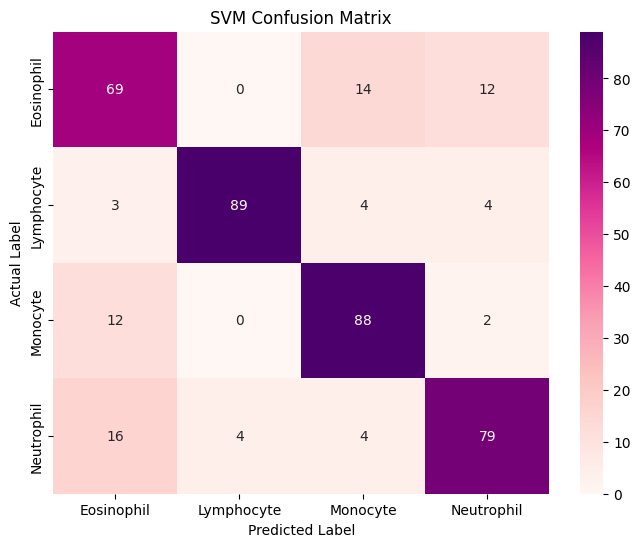

In [40]:
plt.figure(figsize=(8, 6))

sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='RdPu',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

**Observations:**

- The SVM model demonstrated strong classification performance across all blood cell classes.
- Lymphocytes achieved the highest number of correct predictions (89), indicating that they were the easiest class for the SVM model to classify.
- Monocytes also showed excellent performance with 88 correctly classified samples.
- Neutrophils achieved 79 correct predictions, reflecting good classification performance.
- Eosinophils had the lowest number of correct predictions (69), suggesting that they were comparatively more difficult for the SVM model to distinguish.
- The SVM model frequently confused Eosinophils with Monocytes (14 samples) and Neutrophils (12 samples).
- Neutrophils were occasionally misclassified as Eosinophils (16 samples), indicating some overlap in their visual characteristics.
- Overall, the SVM model provided better class-wise performance than KNN and produced relatively balanced predictions across the dataset.

### **7.3 Classification Report for Each Models**

**7.3.1 Classification Report for KNN Model**

In [41]:
report_knn = classification_report(y_test_transf,y_pred_KNN)
print("*"*30,"Classification Report foor KNN","*"*30)
print(report_knn)

****************************** Classification Report foor KNN ******************************
              precision    recall  f1-score   support

           0       0.46      0.73      0.57        95
           1       0.78      0.84      0.81       100
           2       0.69      0.77      0.73       102
           3       0.86      0.24      0.38       103

    accuracy                           0.64       400
   macro avg       0.70      0.65      0.62       400
weighted avg       0.70      0.64      0.62       400



**Observation:**

- The KNN model achieved an overall accuracy of **64%**, showing moderate performance in classifying WBC images. 
- The model performed best on **Class 1** and **Class 2**, with F1-scores of **0.81** and **0.73**, respectively. 
- The model struggled with **Class 3**, achieving a very low recall (**0.24**), indicating difficulty in correctly identifying samples from this class.

**7.3.2 Classification Report for Random Forest Model**

In [42]:
report_RandForest = classification_report(y_test_transf,y_pred_RandForest)
print("*"*30,"Classification Report foor Random Forest","*"*30)
print(report_RandForest)

****************************** Classification Report foor Random Forest ******************************
              precision    recall  f1-score   support

           0       0.82      0.83      0.83        95
           1       0.98      0.89      0.93       100
           2       0.87      0.86      0.87       102
           3       0.84      0.91      0.87       103

    accuracy                           0.88       400
   macro avg       0.88      0.87      0.88       400
weighted avg       0.88      0.88      0.88       400



**Observation:**

- The Random Forest model achieved an overall accuracy of **88%**, indicating strong classification performance on the WBC dataset. 
- The model performed consistently well across all classes, with F1-scores ranging from **0.83 to 0.93**, demonstrating balanced predictions. 
- **Class 1** showed the best performance with an F1-score of **0.93**, while the high recall for **Class 3 (0.91)** indicates that the model effectively identified most samples belonging to this class.

**7.3.3 Classification Report for SVM Model**

In [43]:
report_svm = classification_report(y_test_transf,y_pred_SVM)
print("*"*30,"Classification Report for SVM","*"*30)
print(report_svm)

****************************** Classification Report for SVM ******************************
              precision    recall  f1-score   support

           0       0.69      0.73      0.71        95
           1       0.96      0.89      0.92       100
           2       0.80      0.86      0.83       102
           3       0.81      0.77      0.79       103

    accuracy                           0.81       400
   macro avg       0.82      0.81      0.81       400
weighted avg       0.82      0.81      0.81       400



**Observation:**

- The SVM model achieved an overall accuracy of **81%**, demonstrating strong performance in classifying WBC images. 
- The model performed best on **Class 1**, achieving an F1-score of **0.92**, while maintaining good performance on **Class 2** and **Class 3**. 
- Compared to KNN, SVM provided more balanced predictions across all classes, although **Class 0** remained relatively more challenging with the lowest F1-score of **0.71**.

### **Final Verdict**

- Among the three models, **Random Forest** achieved the best overall performance with an accuracy of **88%** and consistently high precision, recall, and F1-scores across all classes.
- **SVM** ranked second with an accuracy of **81%**, providing balanced predictions and outperforming KNN in most evaluation metrics.
- **KNN** showed the lowest performance with an accuracy of **64%**, struggling particularly with the identification of certain classes.
- Based on the evaluation results, **Random Forest was selected as the final model for WBC classification due to its superior accuracy, robustness, and balanced performance across all white blood cell categories.**


## **8. Exporting the Model**

In [44]:
joblib.dump({
    'model': RandForest_Model,
    'transformer' : Scaler,
    'encoder' : LE
}, 'WBC_Model.pkl')

['WBC_Model.pkl']